# Dynamic Time Warping: Hard and Soft Alignments

[![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gpeyre/ot4ml/blob/main/notebooks-figures/dynamic-time-warping.ipynb)

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:dynamic-time-warping`. It is self-contained on Google Colab: choose **Runtime > Run all**. The setup cell uses the repository checkout when available and otherwise creates a small temporary output tree containing only the shared plotting helper.

For sequences $x=(x_i)_{i=1}^n$ and $y=(y_j)_{j=1}^m$, dynamic time warping minimizes the accumulated feature cost along monotone paths,

$$
\operatorname{DTW}_c(x,y)
=
\min_{\omega\in\Omega_{n,m}}
\sum_{(i,j)\in\omega} c(x_i,y_j).
$$

The experiment compares the minimizing hard path with the Gibbs expected alignment produced by soft-DTW.


In [1]:
# --- OT4ML_COLAB_BOOTSTRAP: standalone local/Colab setup.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request


def _ot4ml_find_repo_root():
    """Locate a checkout containing the shared figure-style module.

    Returns:
        Repository root when a checkout is available, otherwise ``None``.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install ``package_name`` only when ``module_name`` is unavailable.

    Args:
        module_name: Importable Python module to test.
        package_name: Distribution name passed to ``pip`` when needed.

    Returns:
        ``None``.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


def _ot4ml_write_fallback_style(target):
    """Write the small subset of ``figure_style`` required by this notebook.

    Args:
        target: Destination Python module.

    Returns:
        ``None``.
    """
    target.write_text(
        """from pathlib import Path
import matplotlib as mpl

ROOT = Path(__file__).resolve().parents[1]
LATEX_FIGURES = ROOT / "OT4ML" / "figures"
RED = "#d73027"
BLUE = "#2166ac"
GRAY = "#4d4d4d"


def setup_matplotlib():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "font.size": 9,
        "axes.linewidth": 0.75,
        "axes.edgecolor": "#333333",
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def figure_dir(name):
    out = LATEX_FIGURES / name
    out.mkdir(parents=True, exist_ok=True)
    return out


def save_pdf(fig, path, *, pad_inches=0.035):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", pad_inches=pad_inches)
""",
        encoding="utf-8",
    )


for _module, _package in (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
    ("IPython", "ipython"),
):
    _ot4ml_ensure_package(_module, _package)

ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    try:
        _IN_COLAB = _OT4ML_importlib_util.find_spec("google.colab") is not None
    except ModuleNotFoundError:
        _IN_COLAB = False
    ROOT = (
        _OT4ML_Path("/content/ot4ml-figure-runtime")
        if _IN_COLAB
        else _OT4ML_Path.cwd() / "ot4ml-figure-runtime"
    )
    _style_path = ROOT / "notebooks-figures" / "figure_style.py"
    _style_path.parent.mkdir(parents=True, exist_ok=True)
    (ROOT / "notebooks-figures" / "thumbnails").mkdir(parents=True, exist_ok=True)
    (ROOT / "OT4ML" / "figures").mkdir(parents=True, exist_ok=True)
    if not _style_path.exists():
        try:
            _style_url = (
                "https://raw.githubusercontent.com/gpeyre/ot4ml/main/"
                "notebooks-figures/figure_style.py"
            )
            with _OT4ML_urllib_request.urlopen(_style_url, timeout=15) as response:
                _style_path.write_bytes(response.read())
        except Exception as error:
            print(f"Shared style download unavailable ({error}); using the embedded fallback.")
            _ot4ml_write_fallback_style(_style_path)

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

print("OT4ML runtime ready.")


OT4ML runtime ready.


In [2]:
from pathlib import Path
import logging
import os
import sys
import tempfile

_MPLCONFIGDIR = Path(tempfile.gettempdir()) / "mpl-ot4ml"
_MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPLCONFIGDIR))

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

if str(FIGROOT) not in sys.path:
    sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import numpy as np
from scipy.special import logsumexp

from figure_style import BLUE, GRAY, RED, figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "dynamic-time-warping"
OUT = figure_dir(NAME)
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"


## A signal observed through a nonlinear clock

We choose a nonperiodic oscillatory signal and a smooth increasing time warp

$$
\gamma(t)=t+0.105\sin(2\pi t),
\qquad
\gamma'(t)=1+0.21\pi\cos(2\pi t)>0.
$$

The second observation is exactly $y(t)=x(\gamma(t))$. The varying trend and amplitudes reduce the repeated-pattern ambiguity that a purely periodic signal would create.

In [3]:
N_SAMPLES = 105
SOFT_TEMPERATURE = 0.200
TIME = np.linspace(0.0, 1.0, N_SAMPLES)


def reference_signal(time: np.ndarray) -> np.ndarray:
    """Evaluate the oscillatory reference signal.

    Args:
        time: Sample times in the unit interval.

    Returns:
        Signal values with slowly varying trend and oscillation amplitudes.
    """
    time = np.asarray(time, dtype=float)
    return (
        0.72 * np.sin(2.0 * np.pi * (2.15 * time + 0.04))
        + 0.28 * np.sin(2.0 * np.pi * (4.85 * time + 0.17))
        + 0.22 * np.cos(2.0 * np.pi * 1.15 * time)
        + 0.38 * (time - 0.5)
    )


def increasing_warp(time: np.ndarray) -> np.ndarray:
    """Apply the analytic increasing warp used in the experiment.

    Args:
        time: Sample times in the unit interval.

    Returns:
        Warped times with fixed endpoints and strictly positive derivative.
    """
    time = np.asarray(time, dtype=float)
    return time + 0.105 * np.sin(2.0 * np.pi * time)


WARPED_TIME = increasing_warp(TIME)
SOURCE_SIGNAL = reference_signal(TIME)
TARGET_SIGNAL = reference_signal(WARPED_TIME)
COST = (SOURCE_SIGNAL[:, None] - TARGET_SIGNAL[None, :]) ** 2

assert np.isclose(WARPED_TIME[0], 0.0)
assert np.isclose(WARPED_TIME[-1], 1.0)
assert np.all(np.diff(WARPED_TIME) > 0.0)
assert COST.shape == (N_SAMPLES, N_SAMPLES)
assert np.all(COST >= 0.0)

## Exact DTW by dynamic programming

With $C_{ij}=|x_i-y_j|^2$, the accumulated costs satisfy

$$
D_{ij}=C_{ij}+\min\{D_{i-1,j},D_{i,j-1},D_{i-1,j-1}\}.
$$

A predecessor table stores one minimizing move in each cell. Backtracking from the upper-right corner recovers the hard monotone path.

In [4]:
def dtw_dynamic_programming(cost: np.ndarray) -> tuple[float, np.ndarray]:
    """Compute a classical DTW value and one minimizing path.

    Args:
        cost: Nonnegative pairwise cost matrix of shape ``(n, m)``.

    Returns:
        Pair containing the minimum accumulated cost and an integer array of
        zero-based path coordinates, ordered from ``(0, 0)`` to ``(n-1, m-1)``.

    Raises:
        ValueError: If the cost matrix is empty, non-finite, or negative.
    """
    cost = np.asarray(cost, dtype=float)
    if cost.ndim != 2 or min(cost.shape) == 0:
        raise ValueError("cost must be a nonempty matrix")
    if not np.all(np.isfinite(cost)) or np.any(cost < 0.0):
        raise ValueError("cost entries must be finite and nonnegative")

    n_rows, n_columns = cost.shape
    accumulated = np.full((n_rows + 1, n_columns + 1), np.inf)
    predecessor = np.full((n_rows + 1, n_columns + 1, 2), -1, dtype=int)
    accumulated[0, 0] = 0.0

    moves = np.array([[-1, 0], [0, -1], [-1, -1]], dtype=int)
    for row in range(1, n_rows + 1):
        for column in range(1, n_columns + 1):
            candidates = np.array(
                [
                    accumulated[row - 1, column],
                    accumulated[row, column - 1],
                    accumulated[row - 1, column - 1],
                ]
            )
            move = moves[int(np.argmin(candidates))]
            previous = np.array([row, column]) + move
            predecessor[row, column] = previous
            accumulated[row, column] = cost[row - 1, column - 1] + accumulated[
                previous[0], previous[1]
            ]

    path = []
    row, column = n_rows, n_columns
    while (row, column) != (0, 0):
        path.append((row - 1, column - 1))
        row, column = predecessor[row, column]
    path.reverse()
    path_array = np.asarray(path, dtype=int)
    return float(accumulated[n_rows, n_columns]), path_array


DTW_VALUE, DTW_PATH = dtw_dynamic_programming(COST)
assert np.isclose(
    DTW_VALUE,
    COST[DTW_PATH[:, 0], DTW_PATH[:, 1]].sum(),
)
path_steps = np.diff(DTW_PATH, axis=0)
assert np.array_equal(DTW_PATH[0], [0, 0])
assert np.array_equal(DTW_PATH[-1], [N_SAMPLES - 1, N_SAMPLES - 1])
assert np.all(
    np.any(
        np.all(path_steps[:, None, :] == np.array([[1, 0], [0, 1], [1, 1]]), axis=2),
        axis=1,
    )
)

## Soft-DTW as entropy regularization on path space

Soft-DTW replaces each hard minimum by a log-sum-exp soft minimum. Equivalently,

$$
\operatorname{sDTW}_{\epsilon}(C)
=-\epsilon\log\sum_{\omega\in\Omega_{n,m}}
\exp\!\left(-\frac{\langle A_\omega,C\rangle}{\epsilon}\right).
$$

If $q$ is a probability law over monotone paths and
$H(q)=-\sum_\omega q_\omega\log q_\omega$, the same quantity is

$$
\min_q\left\{
\sum_\omega q_\omega\langle A_\omega,C\rangle-\epsilon H(q)
\right\}.
$$

Thus the entropy acts on the **law of the path**, not directly on its mean
alignment matrix. This is the key distinction from entropic OT. The finite path
set also gives the useful check

$$
\operatorname{DTW}(C)-\epsilon\log|\Omega_{n,m}|
\leq \operatorname{sDTW}_{\epsilon}(C)
\leq \operatorname{DTW}(C).
$$

A log-domain forward--backward recursion computes both the free energy and

$$
E_\epsilon=\nabla_C\operatorname{sDTW}_{\epsilon}(C)
=\mathbb E_\epsilon[A_\omega],
$$

the probability that each cell belongs to a random Gibbs path.

In [5]:
def soft_dtw_forward_backward(
    cost: np.ndarray,
    temperature: float,
) -> tuple[float, np.ndarray]:
    """Compute soft-DTW and its expected alignment by log-domain recursions.

    Args:
        cost: Nonnegative pairwise cost matrix of shape ``(n, m)``.
        temperature: Positive Gibbs temperature.

    Returns:
        Pair containing the soft-DTW free energy and the expected path-incidence
        matrix, which is also the gradient with respect to ``cost``.

    Raises:
        ValueError: If the matrix or temperature is invalid.
    """
    cost = np.asarray(cost, dtype=float)
    if cost.ndim != 2 or min(cost.shape) == 0:
        raise ValueError("cost must be a nonempty matrix")
    if not np.all(np.isfinite(cost)) or np.any(cost < 0.0):
        raise ValueError("cost entries must be finite and nonnegative")
    if not np.isfinite(temperature) or temperature <= 0.0:
        raise ValueError("temperature must be finite and positive")

    n_rows, n_columns = cost.shape
    log_forward = np.full_like(cost, -np.inf)
    for row in range(n_rows):
        for column in range(n_columns):
            if (row, column) == (0, 0):
                predecessor_log_weight = 0.0
            else:
                predecessors = []
                if row > 0:
                    predecessors.append(log_forward[row - 1, column])
                if column > 0:
                    predecessors.append(log_forward[row, column - 1])
                if row > 0 and column > 0:
                    predecessors.append(log_forward[row - 1, column - 1])
                predecessor_log_weight = logsumexp(predecessors)
            log_forward[row, column] = (
                predecessor_log_weight - cost[row, column] / temperature
            )

    log_backward = np.full_like(cost, -np.inf)
    log_backward[-1, -1] = 0.0
    for row in range(n_rows - 1, -1, -1):
        for column in range(n_columns - 1, -1, -1):
            if (row, column) == (n_rows - 1, n_columns - 1):
                continue
            successors = []
            if row + 1 < n_rows:
                successors.append(
                    -cost[row + 1, column] / temperature
                    + log_backward[row + 1, column]
                )
            if column + 1 < n_columns:
                successors.append(
                    -cost[row, column + 1] / temperature
                    + log_backward[row, column + 1]
                )
            if row + 1 < n_rows and column + 1 < n_columns:
                successors.append(
                    -cost[row + 1, column + 1] / temperature
                    + log_backward[row + 1, column + 1]
                )
            log_backward[row, column] = logsumexp(successors)

    log_partition = float(log_forward[-1, -1])
    expected_alignment = np.exp(log_forward + log_backward - log_partition)
    soft_value = -temperature * log_partition
    return float(soft_value), expected_alignment


SOFT_DTW_VALUE, SOFT_ALIGNMENT = soft_dtw_forward_backward(
    COST,
    SOFT_TEMPERATURE,
)
# Zero cost evaluates the log-cardinality of the path set exactly.
zero_cost_soft_value, _ = soft_dtw_forward_backward(
    np.zeros_like(COST),
    SOFT_TEMPERATURE,
)
log_path_count = -zero_cost_soft_value / SOFT_TEMPERATURE

assert np.isclose(SOFT_ALIGNMENT[0, 0], 1.0)
assert np.isclose(SOFT_ALIGNMENT[-1, -1], 1.0)
assert np.all((SOFT_ALIGNMENT >= 0.0) & (SOFT_ALIGNMENT <= 1.0 + 1e-10))
assert DTW_VALUE - SOFT_TEMPERATURE * log_path_count <= SOFT_DTW_VALUE + 1e-10
assert SOFT_DTW_VALUE <= DTW_VALUE + 1e-10

# Check that the forward--backward occupancy is the cost gradient.
finite_difference_step = 1e-6
gradient_check_indices = [
    len(DTW_PATH) // 4,
    len(DTW_PATH) // 2,
    3 * len(DTW_PATH) // 4,
]
for path_index in gradient_check_indices:
    row, column = DTW_PATH[path_index]
    perturbation = np.zeros_like(COST)
    perturbation[row, column] = finite_difference_step
    plus_value, _ = soft_dtw_forward_backward(
        COST + perturbation,
        SOFT_TEMPERATURE,
    )
    finite_difference = (plus_value - SOFT_DTW_VALUE) / finite_difference_step
    np.testing.assert_allclose(
        finite_difference,
        SOFT_ALIGNMENT[row, column],
        rtol=2e-3,
        atol=2e-5,
    )

## Hard path and soft occupancy

The two matrix panels use the same pairwise feature-cost scale. The hard optimum is a single red staircase. Soft-DTW instead averages all monotone paths under their Gibbs weights; its red occupancy band is therefore wider where several alignments have comparable accumulated cost.

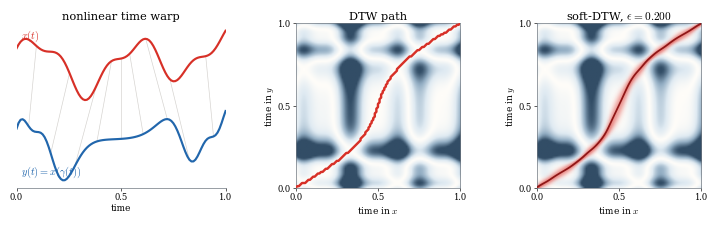

DTW value: 0.106171
soft-DTW value: -30.972846
hard path length: 127
expected soft path length: 177.192


In [6]:
def style_matrix_axes(ax: plt.Axes, title: str) -> None:
    """Apply common geometry and labels to a time-alignment matrix panel.

    Args:
        ax: Matrix axes to style.
        title: Panel title.

    Returns:
        None. The axes are modified in place.
    """
    ax.set_title(title, fontsize=8.2, pad=3.0)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal")
    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(labelsize=6.0, length=2.0, width=0.45, pad=1.5)
    ax.set_xlabel(r"time in $x$", fontsize=6.5, labelpad=1.0)
    ax.set_ylabel(r"time in $y$", fontsize=6.5, labelpad=1.0)
    for spine in ax.spines.values():
        spine.set_color("#6f7780")
        spine.set_linewidth(0.5)


def render_figure() -> plt.Figure:
    """Render and export the hard-versus-soft DTW comparison.

    Returns:
        Matplotlib figure containing the warped curves, hard path, and soft
        expected alignment.
    """
    cost_cmap = LinearSegmentedColormap.from_list(
        "dtw_cost",
        ["#fffdf9", "#dfeaf2", "#91acc2", "#324d66"],
    )
    cost_limit = float(np.quantile(COST, 0.92))
    cost_norm = PowerNorm(gamma=0.62, vmin=0.0, vmax=cost_limit, clip=True)

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(7.25, 2.35),
        gridspec_kw={"width_ratios": [1.18, 1.0, 1.0]},
    )

    signal_ax = axes[0]
    vertical_offset = 1.30
    connector_indices = np.linspace(6, N_SAMPLES - 7, 9, dtype=int)
    for index in connector_indices:
        signal_ax.plot(
            [WARPED_TIME[index], TIME[index]],
            [reference_signal(WARPED_TIME[index]) + vertical_offset,
             TARGET_SIGNAL[index] - vertical_offset],
            color="#a8a39c",
            lw=0.48,
            alpha=0.48,
            zorder=0,
        )
    signal_ax.plot(
        TIME,
        SOURCE_SIGNAL + vertical_offset,
        color=RED,
        lw=1.55,
        zorder=2,
    )
    signal_ax.plot(
        TIME,
        TARGET_SIGNAL - vertical_offset,
        color=BLUE,
        lw=1.55,
        zorder=2,
    )
    signal_ax.text(
        0.02,
        0.91,
        r"$x(t)$",
        color=RED,
        fontsize=7.4,
        fontweight="bold",
        transform=signal_ax.transAxes,
    )
    signal_ax.text(
        0.02,
        0.08,
        r"$y(t)=x(\gamma(t))$",
        color=BLUE,
        fontsize=7.4,
        fontweight="bold",
        transform=signal_ax.transAxes,
    )
    signal_ax.set_title("nonlinear time warp", fontsize=8.2, pad=3.0)
    signal_ax.set_xlim(0.0, 1.0)
    signal_ax.set_xticks([0.0, 0.5, 1.0])
    signal_ax.set_yticks([])
    signal_ax.set_xlabel("time", fontsize=6.5, labelpad=1.0)
    signal_ax.tick_params(axis="x", labelsize=6.0, length=2.0, width=0.45, pad=1.5)
    signal_ax.spines[["left", "right", "top"]].set_visible(False)
    signal_ax.spines["bottom"].set_color("#6f7780")
    signal_ax.spines["bottom"].set_linewidth(0.5)

    hard_ax = axes[1]
    hard_ax.imshow(
        COST.T,
        origin="lower",
        extent=[0.0, 1.0, 0.0, 1.0],
        interpolation="bilinear",
        cmap=cost_cmap,
        norm=cost_norm,
        aspect="auto",
    )
    hard_ax.plot(
        TIME[DTW_PATH[:, 0]],
        TIME[DTW_PATH[:, 1]],
        color=RED,
        lw=1.75,
        solid_capstyle="round",
        zorder=3,
    )
    style_matrix_axes(hard_ax, "DTW path")

    soft_ax = axes[2]
    soft_ax.imshow(
        COST.T,
        origin="lower",
        extent=[0.0, 1.0, 0.0, 1.0],
        interpolation="bilinear",
        cmap=cost_cmap,
        norm=cost_norm,
        aspect="auto",
    )
    normalized_occupancy = np.clip(SOFT_ALIGNMENT.T / SOFT_ALIGNMENT.max(), 0.0, 1.0)
    occupancy_rgba = np.empty((*normalized_occupancy.shape, 4), dtype=float)
    occupancy_rgba[..., :3] = np.array([0.84, 0.12, 0.10])
    occupancy_rgba[..., 3] = 0.86 * np.sqrt(normalized_occupancy)
    soft_ax.imshow(
        occupancy_rgba,
        origin="lower",
        extent=[0.0, 1.0, 0.0, 1.0],
        interpolation="bilinear",
        aspect="auto",
        zorder=2,
    )
    row_mass = SOFT_ALIGNMENT.sum(axis=1)
    barycentric_time = SOFT_ALIGNMENT @ TIME / row_mass
    soft_ax.plot(
        TIME,
        barycentric_time,
        color="#8f1717",
        lw=1.25,
        solid_capstyle="round",
        zorder=3,
    )
    style_matrix_axes(soft_ax, rf"soft-DTW, $\epsilon={SOFT_TEMPERATURE:.3f}$")

    figure.subplots_adjust(
        left=0.035,
        right=0.988,
        bottom=0.18,
        top=0.88,
        wspace=0.34,
    )
    save_pdf(figure, OUT / "dtw-alignment.pdf", pad_inches=0.035)
    THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        THUMBNAIL,
        dpi=230,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white",
    )
    return figure


FIGURE = render_figure()
plt.show()

print(f"DTW value: {DTW_VALUE:.6f}")
print(f"soft-DTW value: {SOFT_DTW_VALUE:.6f}")
print(f"hard path length: {len(DTW_PATH)}")
print(f"expected soft path length: {SOFT_ALIGNMENT.sum():.3f}")

## Figure preview and generated files

The thumbnail below is produced from the same vector figure used by the manuscript. The following cell also exposes direct links to the generated PDF and PNG.


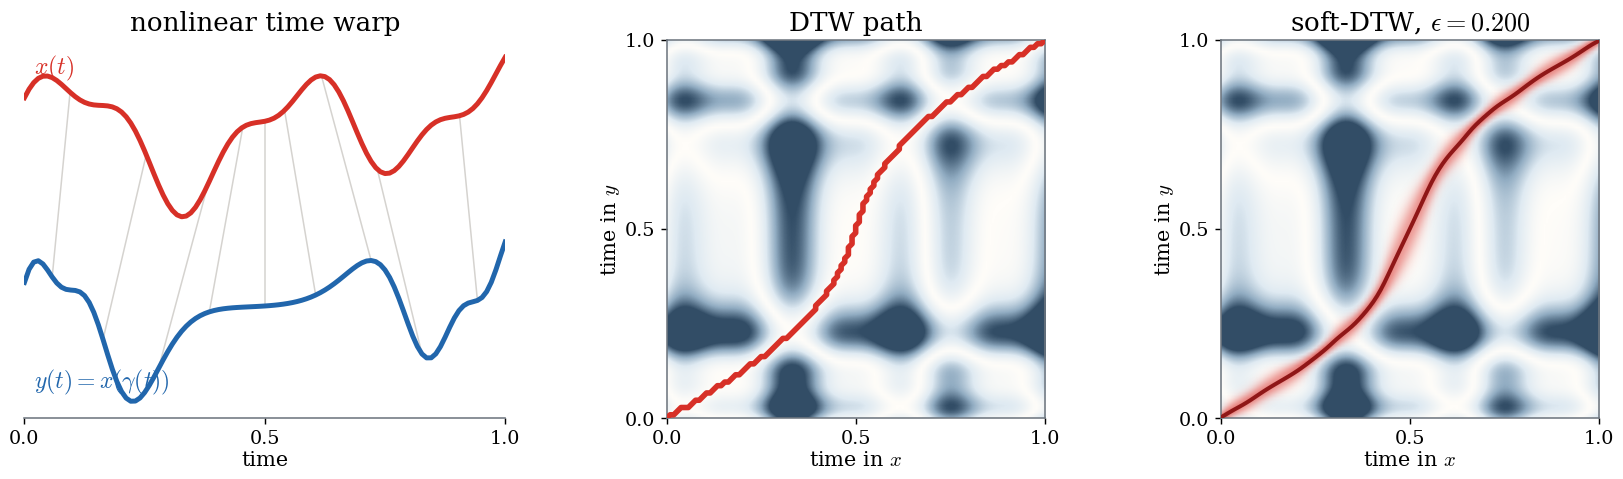

On Colab, call download_generated_files() to download the PDF and PNG.


In [7]:
from IPython.display import HTML, Image as DisplayImage, display

display(DisplayImage(filename=str(THUMBNAIL)))

GENERATED_FILES = (OUT / "dtw-alignment.pdf", THUMBNAIL)
for generated_file in GENERATED_FILES:
    relative_path = generated_file.relative_to(ROOT).as_posix()
    label = generated_file.suffix.upper()[1:]
    display(
        HTML(
            f'{label} output: <a href="{relative_path}" target="_blank">'
            f'{relative_path}</a>'
        )
    )


def download_generated_files() -> None:
    """Download both generated files when the notebook runs on Google Colab."""
    try:
        from google.colab import files
    except ImportError as error:
        raise RuntimeError("This helper is available only on Google Colab.") from error
    for generated_file in GENERATED_FILES:
        files.download(str(generated_file))


print("On Colab, call download_generated_files() to download the PDF and PNG.")
